In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('../../src')))

from pyoma2.algorithms import pLSCF,FSDD,SSIcov
from pyoma2.setup import SingleSetup

In [42]:
data = pd.read_csv("Data.txt", sep='\t')
data = data.to_numpy()

In [43]:
edificio_shell = SingleSetup(data, fs=250)

edificio_shell.def_geo1_by_file("Geo1.xlsx")
edificio_shell.def_geo2_by_file("Geo2.xlsx")

In [44]:
edificio_shell.geo1.bg_nodes

array([[ 0.  , 10.53, 53.35],
       [ 0.  , 15.16, 53.35],
       [ 0.  , 17.16, 53.35],
       ...,
       [16.58, 27.39,  0.  ],
       [21.98, 27.39,  0.  ],
       [11.18, 27.39,  0.  ]], shape=(400, 3))

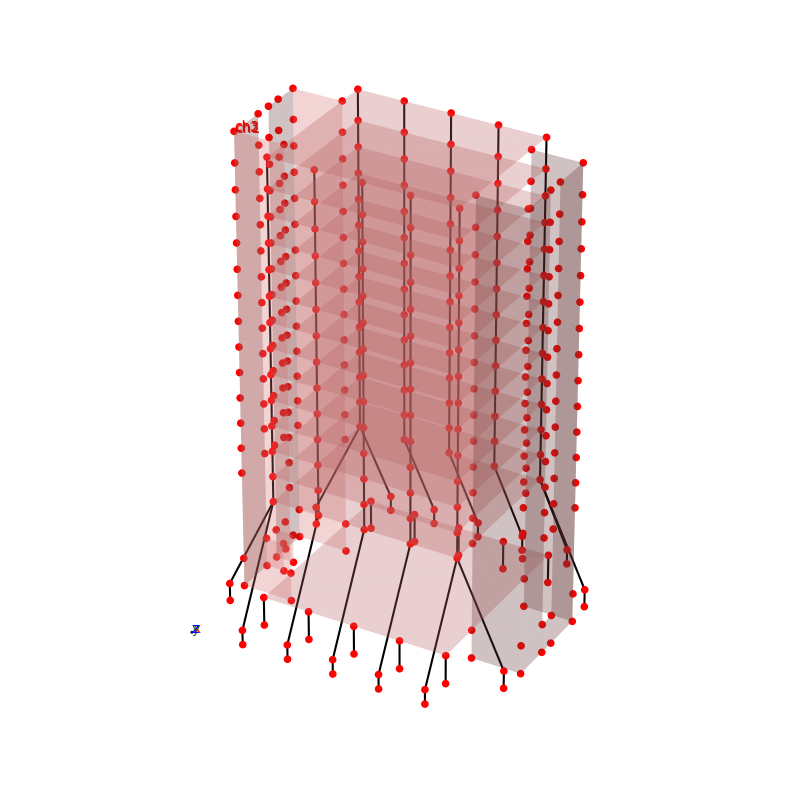

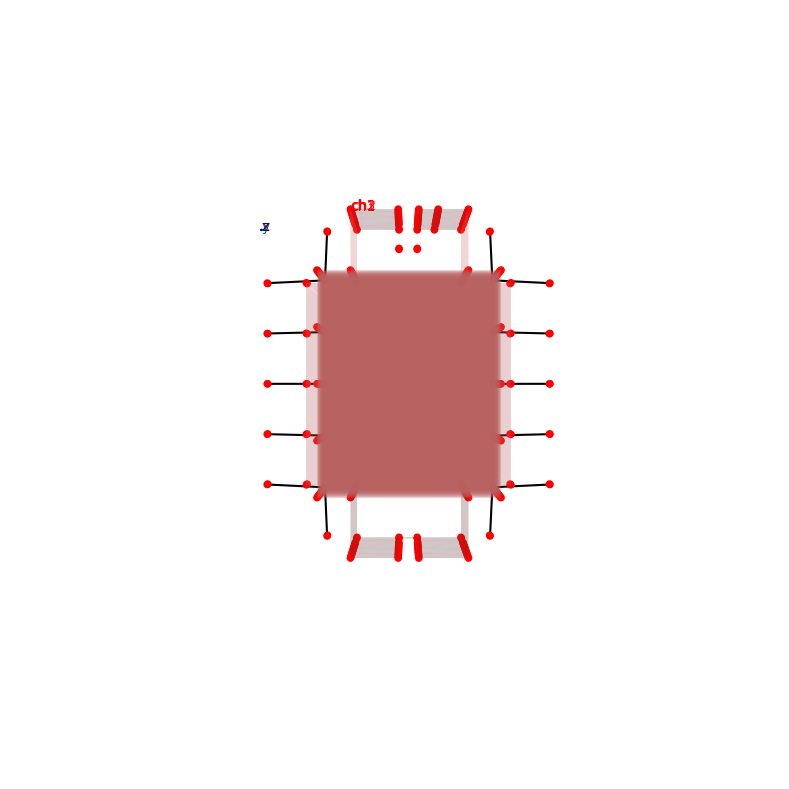

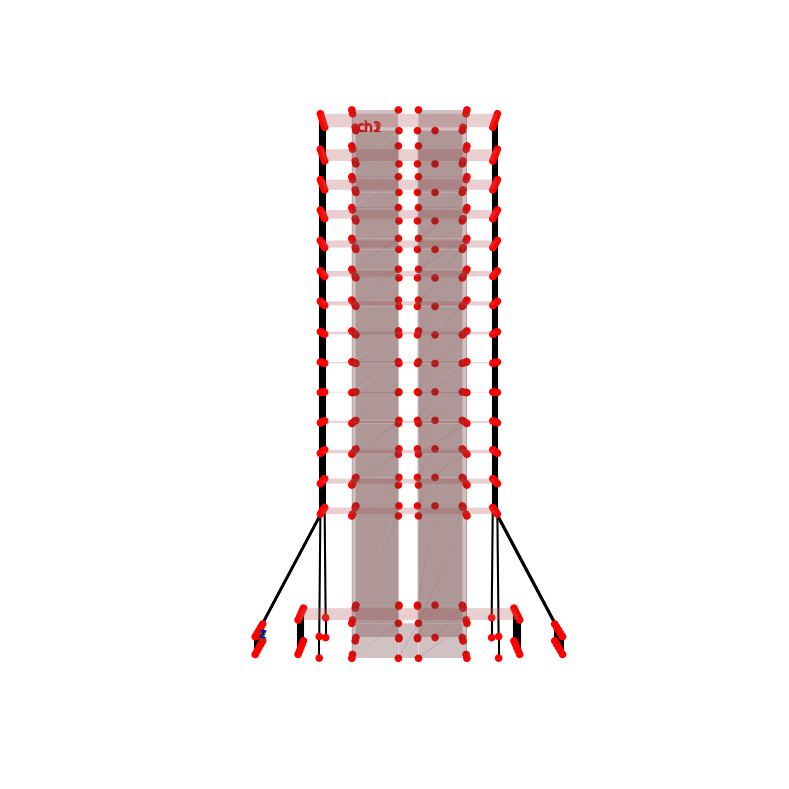

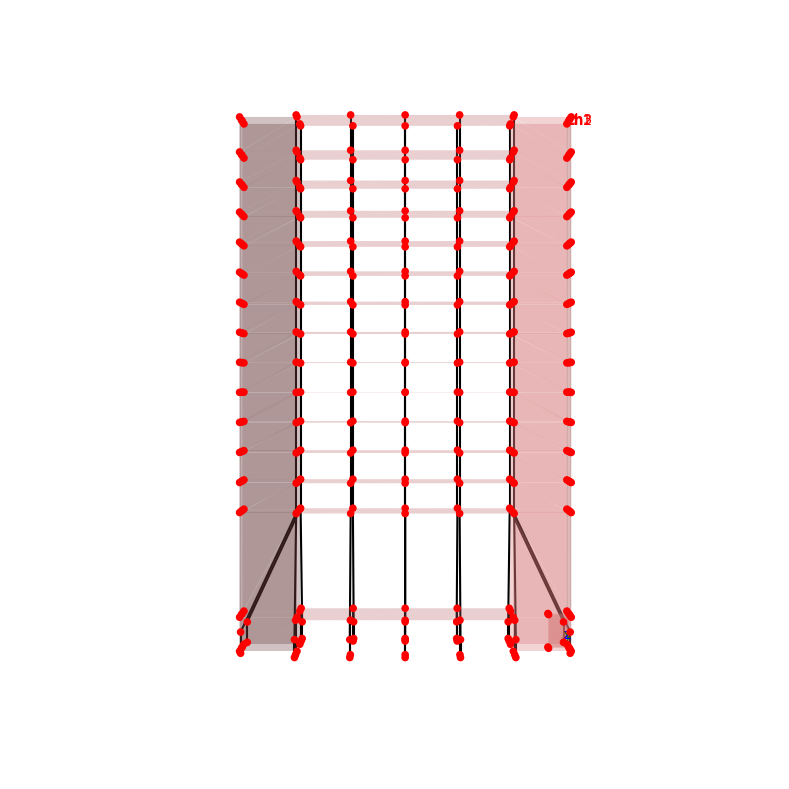

In [46]:
_, _ = edificio_shell.plot_geo2_mpl(scaleF=0.1)
_, _ = edificio_shell.plot_geo2_mpl(scaleF=0.1, view='xy')
_, _ = edificio_shell.plot_geo2_mpl(scaleF=0.1, view='yz')
_, _ = edificio_shell.plot_geo2_mpl(scaleF=0.1, view='xz')

In [ ]:
_, _ = edificio_shell.plot_data(nc=2)

In [ ]:
edificio_shell.filter_data(Wn=(0.1, 25), order=8, btype="bandpass")
edificio_shell.decimate_data(q=5)
#_, _ = edificio_shell.plot_ch_info(ch_idx=[0])

In [ ]:
# Initialise the algorithms
fsdd = FSDD(name="FSDD", nxseg=1024, method_SD="cor")
ssicov = SSIcov(name="SSIcov", br=30, ordmax=30, calc_unc=True)
plscf = pLSCF(name="polymax",ordmax=30)

# Overwrite/update run parameters for an algorithm
fsdd.run_params = FSDD.RunParamCls(nxseg=1024, method_SD="per", pov=0.5)

# Add algorithms to the single setup class
edificio_shell.add_algorithms(ssicov, fsdd, plscf)

# Run all or run by name
edificio_shell.run_by_name("SSIcov")
edificio_shell.run_by_name("FSDD")
edificio_shell.run_by_name("polymax")
# edificio_shell.run_all()

# save dict of results
ssi_res = ssicov.result.model_dump()
#fsdd_res = dict(fsdd.result)
fsdd_res = fsdd.result.model_dump()

In [ ]:
# plot Singular values of PSD
fig1, ax = fsdd.plot_CMIF()
ax.set_xlim(1, 10)
ax.set_ylim(-15, 5)
ax.minorticks_on()
ax.grid(which='major', linestyle='-', linewidth='0.5', color='black')
ax.grid(which='minor', linestyle=':', linewidth='0.5', color='black')

In [ ]:
# plot Stabilisation chart for SSI
_, _ = ssicov.plot_stab(freqlim=(1,10), hide_poles=False)

In [ ]:
# plot frequecy-damping clusters for SSI
_, _ = ssicov.plot_freqvsdamp(freqlim=(1,10))

In [ ]:
# plot Stabilisation chart for pLSCF
_, _ = plscf.plot_stab(freqlim=(1,10), hide_poles=False)

In [ ]:
# Select modes to extract from plots
edificio_shell.mpe_from_plot("FSDD", freqlim=(0.5,15), MAClim=0.95)

# or directly
#edificio_shell.mpe("SSIcov", sel_freq=[1.4, 4.1, 5.6, 6.6, 8.4], order_in=20)
edificio_shell.mpe_from_plot("SSIcov", freqlim=(0.5,15))

# update dict of results
#fsdd_res = dict(fsdd.result)
fsdd_res = fsdd.result.model_dump()
ssi_res = ssicov.result.model_dump()

In [ ]:
print(ssicov.result.Fn)

In [ ]:
fsdd.result.Fn

In [ ]:
# plot additional info (goodness of fit) for EFDD or FSDD
_, _ = edificio_shell[fsdd.name].plot_EFDDfit(freqlim=(0.5,15))

In [ ]:
# Mode shape plots
# Plot mode 1 (geometry 1)
#edificio_shell.plot_mode_geo2_mpl(algo_res=fsdd.result, mode_nr=1, view="3D", scaleF=0.5)
#edificio_shell.plot_mode_geo2_mpl(algo_res=fsdd.result, mode_nr=2, view="3D", scaleF=0.5)
#edificio_shell.plot_mode_geo2_mpl(algo_res=fsdd.result, mode_nr=3, view="3D", scaleF=0.5)
#edificio_shell.plot_mode_geo2_mpl(algo_res=fsdd.result, mode_nr=4, view="3D", scaleF=0.5)
#edificio_shell.plot_mode_geo2_mpl(algo_res=fsdd.result, mode_nr=5, view="3D", scaleF=0.5)

edificio_shell.plot_mode_geo2_mpl(algo_res=ssicov.result, mode_nr=1, view="3D", scaleF=0.5)
edificio_shell.plot_mode_geo2_mpl(algo_res=ssicov.result, mode_nr=2, view="3D", scaleF=0.5)
edificio_shell.plot_mode_geo2_mpl(algo_res=ssicov.result, mode_nr=3, view="3D", scaleF=0.5)
edificio_shell.plot_mode_geo2_mpl(algo_res=ssicov.result, mode_nr=4, view="3D", scaleF=0.5)
edificio_shell.plot_mode_geo2_mpl(algo_res=ssicov.result, mode_nr=5, view="3D", scaleF=0.5)
# Show the plot
plt.show()